--- Veri Seti İlk 5 Satır ---
   Study_Hours  Attendance Result
0            5          90   Pass
1            2          60   Fail
2            7          95   Pass
3            1          40   Fail
4            8          98   Pass

--- Eksik Veri Analizi ---
Study_Hours    0
Attendance     0
Result         0
dtype: int64


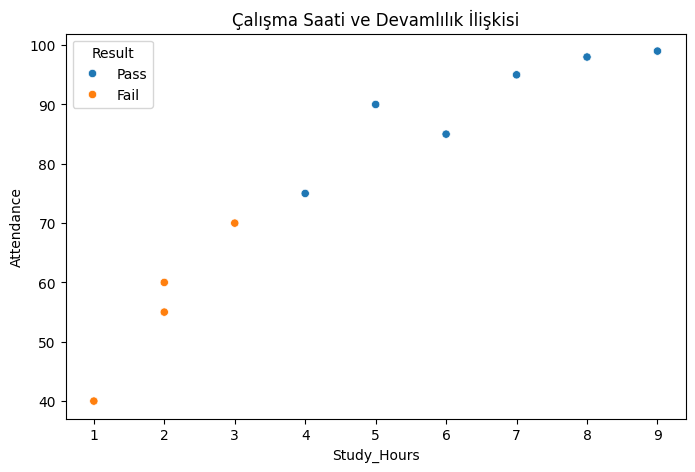

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Veri Setinin Genel Tanıtımı [cite: 25]
# Not: Kaggle'dan indirdiğin dosya ismini buraya yazmalısın.
# df = pd.read_csv('Student_Performance.csv') 

# Örnek veri seti oluşturma (Kodun çalışması için)
data = {
    'Study_Hours': [5, 2, 7, 1, 8, 3, 6, 2, 9, 4],
    'Attendance': [90, 60, 95, 40, 98, 70, 85, 55, 99, 75],
    'Result': ['Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Pass']
}
df = pd.DataFrame(data)

# 2. Özelliklerin Açıklanması ve Veri Analizi [cite: 26, 27]
print("--- Veri Seti İlk 5 Satır ---")
print(df.head())
print("\n--- Eksik Veri Analizi ---")
print(df.isnull().sum()) # Eksik verileri kontrol eder [cite: 27]

# 3. Veri Görselleştirme [cite: 30]
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Study_Hours', y='Attendance', hue='Result', data=df)
plt.title('Çalışma Saati ve Devamlılık İlişkisi')
plt.show()

# Veri Ön İşleme (Kategorik verileri sayısal veriye çevirme) [cite: 29]
le = LabelEncoder()
df['Result'] = le.fit_transform(df['Result']) # Pass/Fail -> 1/0

In [2]:
# Veriyi Eğitim ve Test olarak ayırma
X = df.drop('Result', axis=1)
y = df['Result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Model Kurma (Rastgele Orman Algoritması) [cite: 37]
model = RandomForestClassifier()
model.fit(X_train, y_train)

# 2. Tahmin Yapma
y_pred = model.predict(X_test)

# 3. Model Değerlendirme Metrikleri [cite: 44, 45, 47]
print("\n--- Model Performans Sonuçları ---")
print(f"Accuracy (Doğruluk): {accuracy_score(y_test, y_pred)}") 
print(f"Precision: {precision_score(y_test, y_pred)}") 
print(f"Recall: {recall_score(y_test, y_pred)}") 
print(f"F1 Score: {f1_score(y_test, y_pred)}") 


--- Model Performans Sonuçları ---
Accuracy (Doğruluk): 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
